## Expanding reaction framework

In [1]:
from pathlib import Path
from rdkit import Chem

from src.utils.dataIO import read_monomer_data, read_rxn_mapping_data
from src.utils.datafmt import parse_field_names_and_roles


DATA_DIR = Path('src/monomer_data')

input_data_path = DATA_DIR / 'PolyID_master.csv'
# input_data_path = DATA_DIR / 'subsample_IPU.csv'

# load and parse monomer data file from disc
monomer_df = read_monomer_data([input_data_path])[0]
monomer_df.set_index(monomer_df.columns[0], inplace=True) # alternative to index_cols arg in read function
field_names, field_roles = parse_field_names_and_roles(monomer_df)
monomer_df.rename(columns=field_names, inplace=True)
print(len(monomer_df))

# generate chemically-unique counterpart
monomer_df_unique = monomer_df.drop_duplicates('smiles_canonical')
print(len(monomer_df_unique))

3199
2528


## Defining recursively-enumerated fragment generation protocol

### Util functions

In [2]:
from typing import Iterable
from collections import defaultdict, Counter

from polymerist.genutils.sequences.discernment.inventory import SymbolInventory
from polymerist.genutils.sequences.discernment.enumeration import DISCERNMENTSolver
from polymerist.smileslib.substructures import num_substruct_queries_distinct
from polymerist.rdutils.reactions.reactions import AnnotatedReaction

# hackily correcting aliphatic atom query
from rdkit.Chem import rdqueries

hflinker_query = rdqueries.AAtomQueryAtom()
hflinker_query.ExpandQuery(rdqueries.HasPropQueryAtom('was_dummy'))

from polymerist.rdutils.reactions import fragment
fragment.HEAVY_FORMER_LINKER_QUERY.GetAtomWithIdx(0).SetQuery(hflinker_query)


canonicalize_mol = lambda mol : Chem.CanonSmiles(Chem.MolToSmiles(mol, canonical=True))
def build_reactant_symbol_inventory(rxn : AnnotatedReaction, reactants : Iterable[Chem.Mol]) -> SymbolInventory:
    sym_inv_proto = defaultdict(Counter)
    for reactant in reactants: # "words" are reactant molecules, contain some number of functional groups - NOTE: placed first in case reactants are exhaustible (e.g. generator-like)
        for i, reactant_template in enumerate(rxn.GetReactants()): # "symbols" in this instance are the indices identifying each reactant template
            sym_inv_proto[i][
                canonicalize_mol(reactant) # word "labels" are canonical SMILES, to uniquify reactants
            ] = num_substruct_queries_distinct(reactant, reactant_template) # counts are the number of occurences of a particular functional group in a monomer
    
    return SymbolInventory(sym_inv_proto)

In [42]:
from typing import ClassVar, Generator
from math import ceil
from itertools import (
    combinations,
    product as cartesian_product,
)

import networkx as nx

from polymerist.rdutils.rdgraphs import rdmol_to_networkx
from polymerist.rdutils.labeling.molwise import atom_ids_by_map_nums

from polymerist.rdutils.reactions.fragment import IBIS
from polymerist.rdutils.reactions.reactions import RxnProductInfo


# defining new fragmentation strategies
HEAVY_FORMER_LINKER_QUERY_ATOM : Chem.QueryAtom = rdqueries.HasPropQueryAtom('was_dummy') # query for atoms with the property "was_dummy" set
HEAVY_FORMER_LINKER_QUERY_ATOM.ExpandQuery(rdqueries.AAtomQueryAtom()) # expand query to only match heavy atoms

def bridgehead_atom_ids(product : Chem.Mol) -> Generator[int, None, None]:
    '''
    Generates the indices of all atoms in a reaction product which were tagged
    as R-group bridgehead (i.e. wild) atoms in the reaction template definition
    '''
    for bh_atom in product.GetAtomsMatchingQuery(HEAVY_FORMER_LINKER_QUERY_ATOM):
        yield bh_atom.GetIdx()

class CutBridgesOrNewBonds(IBIS):
    '''
    IBIS which cleaves bonds in the following descending order of preference:
    -- New bonds between R-group atoms which are also bridge bonds
    -- Bonds which are bridges only
    -- Bonds which are new only
    -- Random choice, if none of the above are present 
    ''' # DEVNOTE: the "random choice" default is not currently implemented
    CUT_COST_KW : ClassVar[str] = 'capacity' # name of edge attribute which stores the cost of each edge being cut
    MAX_BONDS_PER_CUT : ClassVar[int] = 1 # greatest number of bonds allowed to be broken per cut

    # 0) set weights for network flow optimization problem
    BASE_EDGE_CUT_COST : ClassVar[float] = 2.0
    BRIDGE_DISCOUNT    : ClassVar[float] = 0.5 
    NEW_BOND_DISCOUNT  : ClassVar[float] = 0.25

    assert BASE_EDGE_CUT_COST > (BRIDGE_DISCOUNT + NEW_BOND_DISCOUNT) # all weights must remain positive even after the maximum possible deduction
    assert BRIDGE_DISCOUNT > NEW_BOND_DISCOUNT # force bridge bonds to be given priority over new bonds in the even of a tie
    
    def locate_intermonomer_bonds(self, product: Chem.Mol, product_info : RxnProductInfo) -> Generator[int, None, None]:
        # 1) initialize molecular graph
        rdgraph = rdmol_to_networkx(product) # DEVNOTE: the properties required here could be significantly relax
        
        ## 1a) extract subgraph for atoms active in reaction (simplifies computation) 
        ## This implicitly disallows ring cutting for intra-molecular reactions
        mapped_atom_ids = [ 
            atom.GetIdx()
                for atom in product.GetAtoms()   # NOTE: assumes reacting atoms are mapped while the rest are not; may want to
                    if atom.GetAtomMapNum() != 0 # may revisit this assumption in the furute if it becomes brittle
        ]
        active_subgraph = rdgraph.subgraph(mapped_atom_ids)

        ## 1b) Set costs for cutting bonds
        nx.set_edge_attributes(active_subgraph, self.BASE_EDGE_CUT_COST, name=self.CUT_COST_KW)
        ### decrement weights for bridges
        for (atom_idx_begin, atom_idx_end) in nx.bridges(active_subgraph):
            active_subgraph[atom_idx_begin][atom_idx_end][self.CUT_COST_KW] -= self.BRIDGE_DISCOUNT
            
        ### decrement weights for newly-formed bonds
        for template_bond_id, bond_atom_maps_nums in product_info.new_bond_ids_to_map_nums.items():
            atom_idx_begin, atom_idx_end = atom_ids_by_map_nums(product, *bond_atom_maps_nums)
            active_subgraph[atom_idx_begin][atom_idx_end][self.CUT_COST_KW] -= self.NEW_BOND_DISCOUNT
            
        # 2) identify minimal cut-sets between all pairs of R-group bridgeheads
        bonds_already_cut : set[int] = set()
        for bh_atom_pair in combinations(bridgehead_atom_ids(product), 2):
            try:
                flow_across_cut, partition = nx.minimum_cut(active_subgraph, *bh_atom_pair, capacity='capacity')
            except nx.NetworkXUnbounded:
                continue
            else:
                cut_edges = [ # TODO: find cleverer way to count number of cuts based on flow value (which we haven't used here)
                    edge_nodes
                        for edge_nodes in cartesian_product(*partition)
                            if active_subgraph.has_edge(*edge_nodes)
                ]
                if len(cut_edges) <= self.MAX_BONDS_PER_CUT:
                    for edge_nodes in cut_edges:
                        edge_idx = product.GetBondBetweenAtoms(*edge_nodes).GetIdx()
                        
                        if edge_idx not in bonds_already_cut:
                            yield edge_idx
                            bonds_already_cut.add(edge_idx)

### Fetching reactants and reaction template

ester


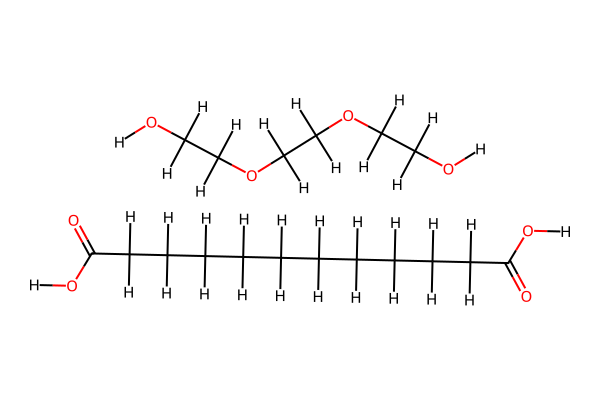

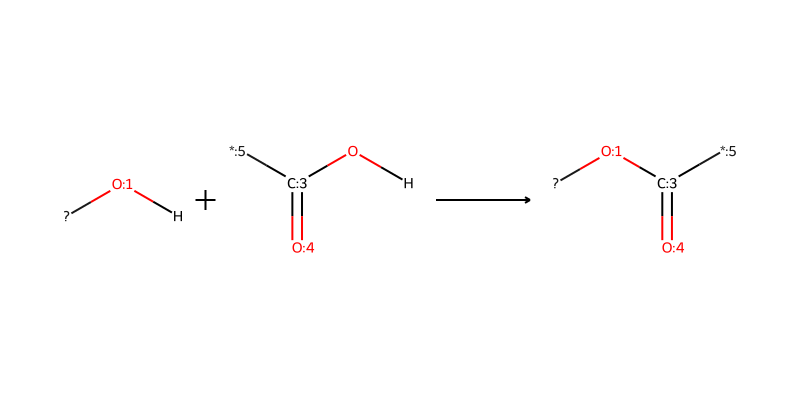

In [44]:
from polymerist.rdutils import set_rdkdraw_size
set_rdkdraw_size(400, 3/2)

from polymerist.rdutils.reactions.reactors import PolymerizationReactor
from polymerist.rdutils.reactions.assembly import ReactionAssembler

sample = monomer_df_unique.groupby('mechanism').sample(1)
idxs_by_mechanism = {mechname : idx for idx, mechname in sample['mechanism'].to_dict().items()}

mechanism : str = 'amide'
mechanism : str = 'imide'
# mechanism : str = 'vinyl'
# mechanism : str = 'carbonate'
mechanism : str = 'ester'
row = sample.loc[idxs_by_mechanism[mechanism]]
print(row.mechanism)


# get reactants
monomers = Chem.MolFromSmiles(row.smiles_explicit, sanitize=False)
Chem.SanitizeMol(monomers)
reactants = Chem.GetMolFrags(monomers, asMols=True)
display(monomers)

# get reaction
rxn = AnnotatedReaction.from_smarts(row.rxn_smarts)
display(rxn)

### Prototype protocol

In [45]:
import logging
logging.basicConfig(
    level=logging.INFO,
    force=True,
)
from collections import defaultdict, Counter

from polymerist.polymers.monomers.specification import expanded_SMILES, compliant_mol_SMARTS

# hackily correcting aliphatic atom query
from polymerist.rdutils.reactions.fragment import ReseparateRGroupsUnique, HEAVY_FORMER_LINKER_QUERY
from polymerist.rdutils.labeling.molwise import clear_atom_map_nums, clear_atom_isotopes
from polymerist.rdutils.bonding.portlib import get_num_ports


reactants_inventory = {
    canonicalize_mol(reactant) : reactant
        for reactant in reactants
}
funct_counts = Counter()
monomers : dict[str, list[Chem.Mol]] = {}

word = [i for i in range(rxn.GetNumReactantTemplates())]
reactor = PolymerizationReactor(rxn)
# frag_strategy = ReseparateRGroupsUnique()
frag_strategy = CutBridgesOrNewBonds()
monomer_prefix : str = 'M'
# TODO: set limit on number of rounds/max functionality

n_new_frags : int = -1
round : int = 1
prods = []

while n_new_frags != 0:
    logging.info(f'ROUND {round}:')
    n_new_frags = 0
    sym_inv = build_reactant_symbol_inventory(rxn, reactants_inventory.values())
    solver = DISCERNMENTSolver(sym_inv)
    for soln in solver.enumerate_choices(word, ignore_multiplicities=True):
        for i, adduct in enumerate(
            reactor.react(
                [reactants_inventory[canon_smi] for canon_smi in soln],
                repetitions=1,
                clear_props=False,
            )
        ):
            Chem.SanitizeMol(adduct)
            prods.append(adduct)
            
            for frag in frag_strategy.produce_fragments(adduct, rxn.product_info_maps[i], separate=True):
                frag = clear_atom_isotopes(clear_atom_map_nums(frag))
                canon_smi = canonicalize_mol(frag)
                funct = get_num_ports(frag)
                # display(frag)
                
                if (canon_smi not in reactants_inventory):# and (funct > 0):
                    logging.info(f'Found new fragment with SMILES: {canon_smi}')
                    reactants_inventory[canon_smi] = frag # add to pool of potential reactants
                    
                    monomers[f'{monomer_prefix}{funct}-{funct_counts[funct]}'] = [compliant_mol_SMARTS(expanded_SMILES(canon_smi, assign_map_nums=True))]
                    funct_counts[funct] += 1 # increment after getting functionality
                    n_new_frags += 1
    round += 1
    if n_new_frags == 0:
        logging.info('Found no new fragments; STOPPING!')

INFO:root:ROUND 1:


INFO:root:Found new fragment with SMILES: *OCCOCCOCCO
INFO:root:Found new fragment with SMILES: *C(=O)CCCCCCCCCCC(=O)O
INFO:root:ROUND 2:
INFO:root:Found new fragment with SMILES: *C(=O)CCCCCCCCCCC(*)=O
INFO:root:Found new fragment with SMILES: *OCCOCCOCCO*
INFO:root:ROUND 3:
INFO:root:Found no new fragments; STOPPING!


M1-0


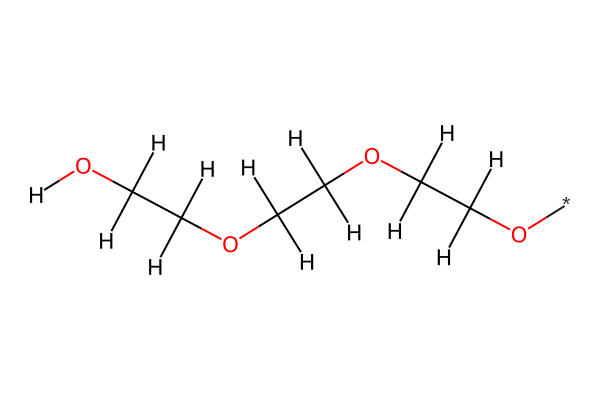

M1-1


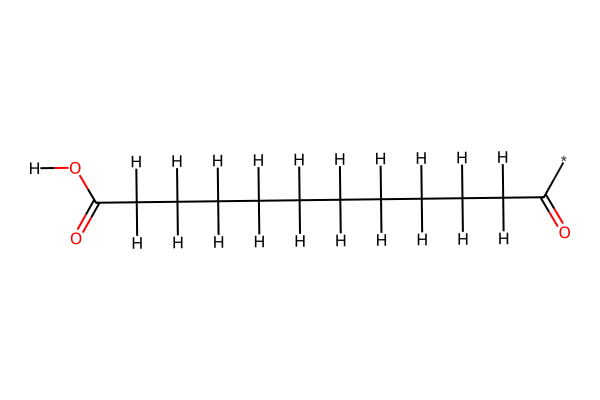

M2-0


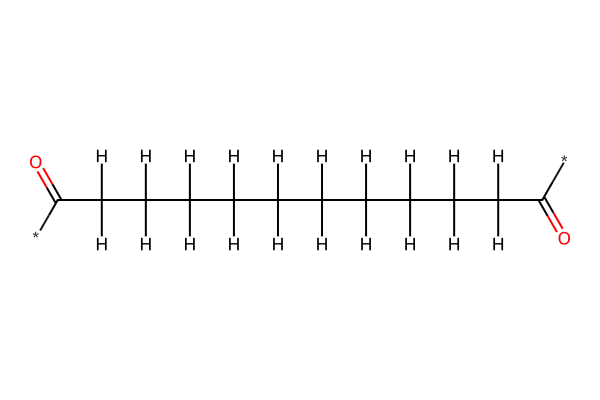

M2-1


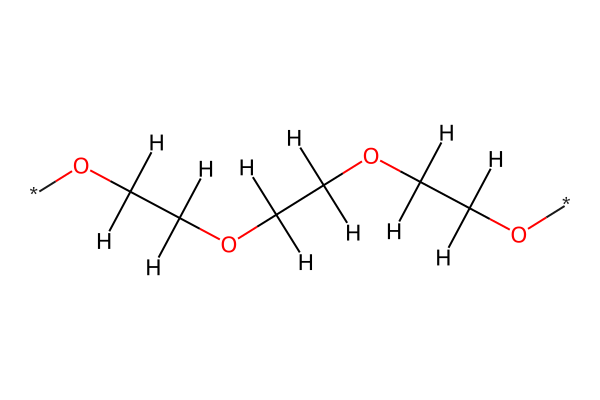

In [46]:
from polymerist.polymers.monomers import MonomerGroup

monogrp = MonomerGroup(monomers)
for name, mol in monogrp.iter_rdmols():
    print(name)
    display(clear_atom_map_nums(mol))

In [29]:
from polymerist.polymers.monomers import MonomerGroup
from polymerist.polymers.building import build_linear_polymer, mbmol_to_rdmol, mbmol_to_rdkit_pdb


n_monomers : int = 20

monogrp = MonomerGroup(monomers)
chain = build_linear_polymer(
    monogrp,
    n_monomers=n_monomers,
    sequence='A',
    energy_minimize=True
)
chain.visualize()

KeyboardInterrupt: 

In [ ]:
mbmol_to_rdkit_pdb('test.pdb', chain)

## Benchmark of interchange export

In [1]:
from cProfile import Profile
from pstats import Stats
from io import StringIO

from openff.toolkit import Molecule, ForceField


def profiler_stats_to_csv(
        csv_path : str,
        profiler : Profile,
        strip_dirs : bool=True,
        sort_by : str | None=None,
    ) -> None:
    '''Helper method to handle I/O of profiling statistics in a machine-readable manner'''
    assert(csv_path.endswith('.csv'))
    
    with StringIO() as stream:
        stats = Stats(profiler, stream=stream)
        if strip_dirs:
            stats = stats.strip_dirs()
            
        if sort_by:
            stats = stats.sort_stats(sort_by)

        # produce and record header line 
        stats.print_title()
        header = stream.getvalue() # record header
        header_list = header.split()
        last_col_idx = len(header_list) - 1

        # flush buffer, produce and record stats lines
        stream.seek(0)
        stream.truncate(0)
        stats.print_stats()
        profile_lines = stream.getvalue().split('\n')
        
    reading : bool = False
    with open(csv_path, 'w', newline='\n') as file:
        for line in profile_lines:
            if not line:
                continue # skip empty lines

            line_list = line.strip().split() #cut out whitespace and newlines
            if line_list == header_list:
                reading = True
                
            if reading:
                # correct for overly-aggresive string space stripping for modules colunm
                line_list_clean = line_list[:last_col_idx] + [' '.join(line_list[last_col_idx:])] 
                line_csv = ','.join(line_list_clean) + '\n'
                file.writelines(line_csv)

if __name__ == '__main__':
    n=1_200
    repeat_unit='CCO' # PEG
    # repeat_unit='c1c(CCCCCC)cc(s1)' # P3HT
    ff_name : str='openff-2.2.1.offxml'
    
    profiler = Profile()
    offmol = Molecule.from_smiles(n * repeat_unit)
    offmol.assign_partial_charges(partial_charge_method='zeros')
    ff = ForceField(ff_name)
    
    interchange = profiler.runcall(
        ff.create_interchange,
        topology=offmol.to_topology(),
        charge_from_molecules=[offmol],
    )

In [2]:
profiler_stats_to_csv('profile.csv', profiler, strip_dirs=True, sort_by='cumulative')

In [12]:
import pandas as pd

df = pd.read_csv('inc_times.csv')
df.sort_values('percall', ascending=False).head(15)

# Something else